# Chapter 9 | Introduction to Artificial Neural Networks

## Table of Content
1. [Introduction](#1-introduction)
2. [From Biological to Artificial Neurons](#2-from-biological-to-artificial-neurons)
3. 

## 1. Introduction
Birds insipired us to fly; similarly, brain's architecture inspired how to build intelligent machines: this is the logic behind **Artificial Neural Networks (ANNs)**, which are ML models inspired by the networks of **Biological Neurons**.
But planes don't flap their wings to fly as birds do; similarly, ANNs have gradually become quite different from their biological cousins.

ANNs are at the core of **Deep Learning**; being versatile, powerful and scalable, they are well-suited for large and highly complex ML tasks:
- classyifying billions of images (e.g., Google Images);
- powering speech recognition services (e.g., Siri);
- powering chatbots (e.g., ChatGPT);
- recommending (e.g., Youtube);
- learning how proteins fold (e.g., DeepMind's AlphaFold).

in this chapter, we'll start implementing simple **Multilayer Percerceptrons** with Scikit-Learn, then we'll switch to PyTorch in the next chapter. Before doing so, let's study the origins of ANNs:



## 2. From Biological to Artificial Neurons 
In 1943, neurophysiologist McCulloch and matgematician Walter Pitts published ["A Logical Calculus of Ideas Immanent in Nervous Activity"](https://scholar.google.com/scholar?q=A+Logical+Calculus+of+Ideas+Immanent+in+Nervous+Activity+author%3Amcculloch), a paper in which they presented a simplified computational model of how biological neurons might work using **Propositional Logic**: this is the first Artificial Neural Newtork architecture.

Since then, an early success of ANNs spread, with the belief that we would soon be conversing with truly intelligent machines: many ANNs architecture have been invented, until in 1960, it became clear the promises would go unfulfilled (at least for a while).

In the early 1980s, new **Connectionism** (i.e., study of Neural Networks) architecture and training techniques were developed, but since progress was slow and since ML offered better results and stronger theoretical foundations tha ANNs (by the 1990s other powerful ML techniques had been invented, such as Support Vector Machines), the study of ANNs was again put on hold.

Nowadays we are living inside a new wave of interes in ANNs, but this time it seems different:
- huge quantity of data to train ANNs (ANNs usually outperforms ML techniques on very large and complex problems);
- tremendous increase in computing power since 1990s (**Moore's Law**: number of components in integrated circuits has doubled about every 2 years over the last 50); this is mostly due to the **Gaming Industry** stimulating production of **Graphical Processing Units (GPUs)**: GPUs were initially designed to accelerate graphics, but it turns out that matrix multiplication (and others) are similar computations;
- training algorithms have been improved;
- theoretical limitations of ANNs turned out to not be such big problems (e.g., ANNs are likely to get stucked in Local Optimum, but this often perform almost as well as the global one);
- invention of **Transformer** architecture in 2017: 
  - it processes and generates all sorts of data (e.g., text, images, audio), while before we had specialized architecture; 
  - it scales rather well, allowing to train very large **Foundation Models**, which are models that can be reused across many different tasks with bit of Fine-Tuning (Transfer Learning) or right prompting (**In-Context Learning (ICL)**, which involves both **Few-Shot Learning (FSL)**, meaning we give it few examples of the task, or **Chain-of-Thought (CoT)**, meaning we ask it to reason step-by-step).
- entering of a virtuous circle of funding and progress which take to a wild pace of innovation.

### Biological Neurons

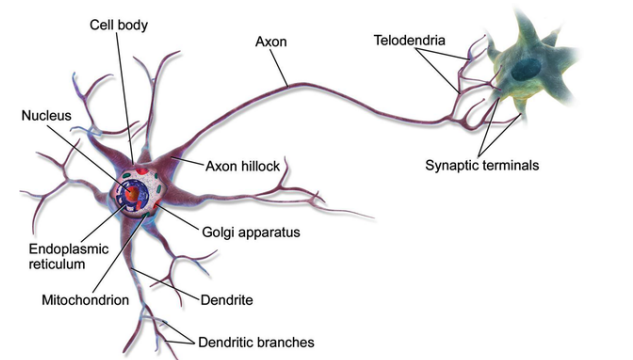

A **Biological Neuron** is an unusual-looking cell mostly found in animal brains.

It is composed of a **Cell Body**, containing the **Nucleus** and most of the cell's complex components, such as the **Dendrites** (branching extensions) and the **Axon** (one very long extension). The axon's length may be few times longer than the cell body, or up to tens of thousands of times longer. At its extremity, the axon splits off into many branches called **Telodendria**, which have on the top minuscule structure called **Synaptic Terminals** (or **Synapses**), connected to other neurons.

Biological Neurons produce short eletrical impulses called **Action Potentials (APs)** (or just **Signals**), which travel along the axons and make the synapses release chemical signals called **Neurotransmitters**. When a neuron receives a sufficient amount of these neurotransmitters within a few milliseconds, it fires its own electrical impulses (actually, some of these neurotransimtter inhibit the neuron from firing).

Individual biological neurons seem to behave simply, but they are organized in a vast network of billions, with each neuron typically connected to thousands of other neurons (usually consecutive layers of neurons). This takes highly complex computations to be performed by a network of fairly simple neurons. Below an image of multiple layers of biological neural networks in the human cortex.

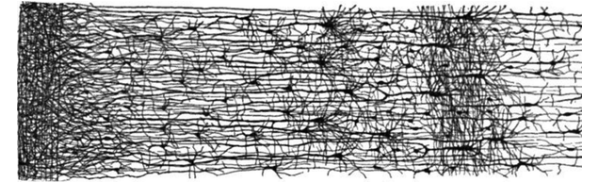

### Artificial Neurons
As we said, McCulloch and Pitts proposed a very simple model of the Biological Neuron, which later become known as **Artificial Neuron**: this has more Binary Inputs and one Binary Output; with such a simplified model it is possible to build a network of artificial neurons computing any logical proposition you want; let's see an example:

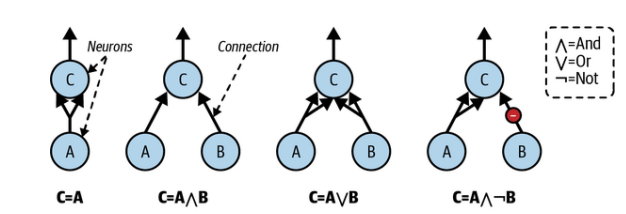

- First Network is the Identity Function: if neuron A is activated, C is activated, otherwise it is not;
- Second Network is a logical AND: if both A and B are activated, C is activated, otherwise it is not;
- Third Network is a logical OR: if either A or B is activated, C is activated, otherwise it is not;
- Fourth Network is a logical AND with a logical NOT: if A is activated and B is not, C is activated, otherwise it is not.

Combining these networks allows to compute complex logical expressions.

#### Perceptron
In 1957m Frank Rosenblatt proposed the **Perceptron**, one of the simplest ANN architectures. It is based on a slightly different artificial neuron called a **Threshold Logic Unit (TLU)**, or sometimes a **Linear Threshold Unit (LTU)**.

The inputs and outputs are Numbers (instead of Binary values) and each input conneciton is associated with a **Weight**. The TLU computes a linear function of its inputs:

$$z = w_1x_1 + w_2x_2 + ... + w_nx_n + b = w^Tx + b$$

It then computes a **Step Function** to the result:

$$ h_w(x) = step(z)$$

This is similar to the Logistic Regression, except it uses a Step Function instead of the Logistic Function

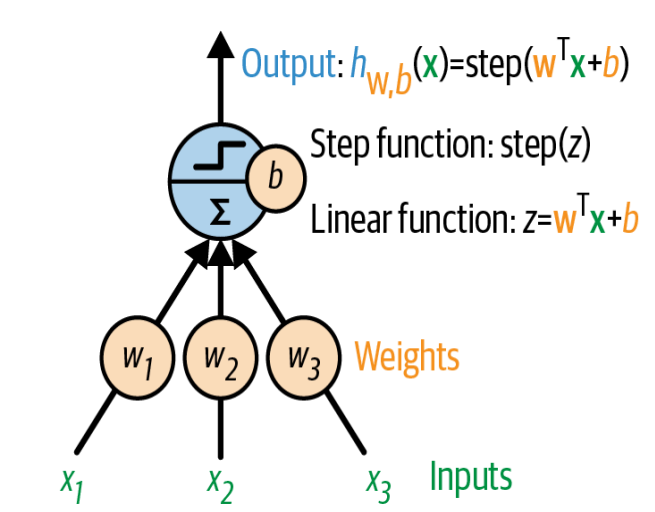

The most common step function used in Perceptrons is the **Heaviside Step Function**:

$$ heaviside (z) = \left\{ \begin{array}{l} 0 & if \space z < 0 \\ 1 & if \space z \ge 0 \end{array} \right.$$

This single TLU can be used for Simple Linear Binary Classification: it computes a linear function of its inputs and if the result exceeds a threshold it outputs the positive class, otherwise the negative one.

A perceptron is composed of one ore more TLUs organized in a single layer, where every TLU is connected to every input: this is called a **Fully Connected Layer** or **Dense Layer** where the inputs consistute the **Input Layer** and the last layer (in this case the TLUs layer) is the **Output Layer**.

Below an image of a Perceptron with 2 inputs and 3 outputs:

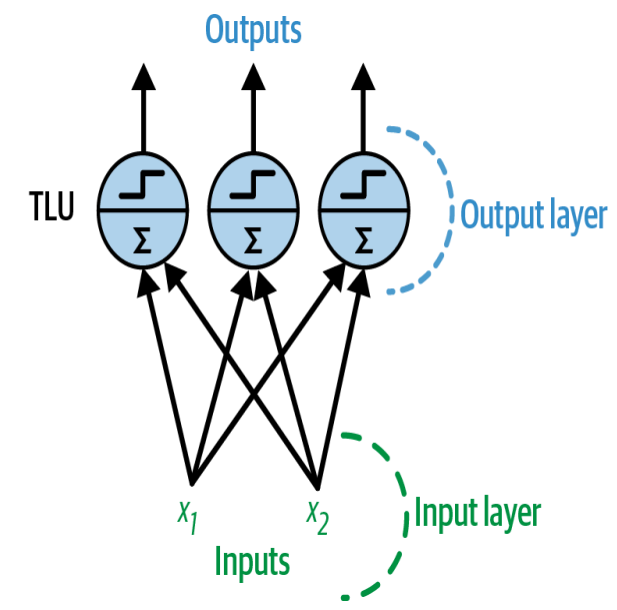

Since the above has 3 outputs, it can be used as a multilabel classifier; moreover, thanks to the magic of linear algebra, we can also combine the outputs to get the Output of a Fully Connected Layer:

$$ \hat Y = \phi (XW + b)$$

where:
- $\hat Y $ is the **Output Matrix** (one row per instance, one column per neuron);
- $X$ is the **Input Matrix** (one row per instance, one column per input feature);
- $W$ is the **Weight Matrix** containing all the Connection Weights (one row per input feature, one column per neuron);
- $b$ is the **Bias Vector** containing all the Bias Terms (one per neuron);
- $\phi$ is the **Activation Function** (in case of TLUs, it is a Step Function).

Note how in Mathematics the sum of a matrix and a vector is undefined; in Data Science we allow this operation in the meaning of adding the vector to every row in the matrix (so above we add $b$ to every row of the matrix obtained by $XW$).

The perceptron training comes from a variant of the **Hebb's Rule** (or **Hebbian Learning**), which comes from an idea that can be summarized with the phrase:

    "Cells that fire together, wire together"

This suggests how the connection weight between two neurons tends to increase when they fire simultaneously. If we also take into account the error made by the network when it makes the prediction, we can reinforce the connections that would help reducing the error: we obtain the **Perceptron Learning Rule** telling us how to **Update the Weights**:

$$ w_{i, j}^{(next \space step)} = w_{i, j} + \eta(y_i - \hat y_i) x_i$$

where:
- $w_{i,j}$ is the **Connection Weight** between $i^{th}$ input and $j^th$ neuron;
- $x_i$ is the $i^{th}$ input value of the current training instance;
- $\hat y_i$ is the output of the $j^{th}$ output neuron for the current training instance;
- $y_i$ is the target output of the $j^{th}$ output neuron for the current training instance;
- $\eta$ is the learning rate.

Just like Logistic Regression, the decision boundary of each output neuron is linear, making perceptrons incapable of learning complex patterns. However if training instances are linarly separable, this algorithm will converge to a solution due to the **Perceptron Convergence Theorem**.

In Scikit-Learn we can use the **Perceptron** class:


In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)', 'petal width (cm)']].values
y = (iris.target == 0) # Binary task: is it Iris Setosa or not?

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)
y_pred

array([ True, False])

You may have noticed similarities between the Perceptron Learning Algorithm and Stochastic Gradient Descent; in fact the `Perceptron` lass is equivalent to using `SGDClassifier` with following hyperparameters: `loss = "perceptron"`, `learning_rate = "constant"`, `eta0 = 1` (this is the learning rate), `penalty = None` (no regularization).

Even if Perceptron trains a bit faster, they do not output class probabilities, they do not use any regularization by default and training stops when there are no more predictions errors on the training set (proned to overfitting). All of this underlines why we generally prefer to use other models such as Logistic Regression or SVM classifier.

Perceptrons have big limits, such as the ones previously listed and being incapable of solving trivial problems (e.g., the **Exclusive OR (XOR)** classification problem, which no other linear model can solve, but researchers expected more from Perceptrons). This disappointment made researchers drop neural networks for a bit.

It turns out that some of the limitations of Perceptrons can be eliminated by stacking multiple Perceptrons, resulting in an ANN called **Multilayer Perceptron (MLP)**.

#### Multilayer Perceptron (MLP) and Backpropagation
An **MLP** is composed of one Input Layer, one or more layers of artificial neurons called Hidden Layers and one final layer of artificial neurons called Output Layer. Layers close to the Input Layer are usually called **Lower Layers**, while ones close to the Outputs are usually called **Upper Layers**.

Below an image of a MLP with one Input Layer with 2 Inputs, one Hidden Layer with 4 Neurons and one Output Layer with 3 Neurons:

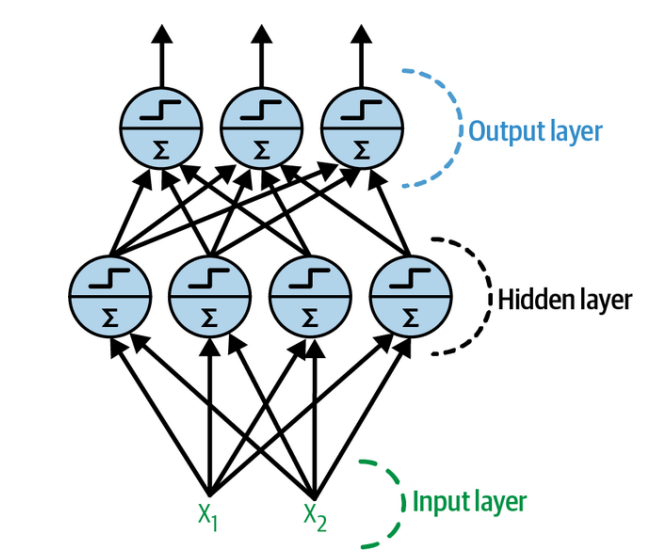

Considering the signal flows in one direction (from inputs to outputs) this is also called **Feedforward Neural Network (FNN)**.

When an ANN contains a deep stack of hidden layers it is called a **Deep Neural Network (DNN)** and the field studing this is called **Deep Learning**.

In the early 1960s, the main problem was to find a way to train MLPs: they discussed the possibility of using Gradient Descent, but this requires computing the gradients of the model's erro rwith regard to the model parameter: at that time, it wan't clear how to this efficiently with so many paameters and the computers they had.

In 1970, researcher Sepo Linnainmaa introduced in his master's thesis a technique to compute the gradients automatically and efficiently, nowadays called **Reverse-Mode Automatic Differentiation** (or **Reverse-Mode Autodiff**): in 2 passes throught the network (one forward, one backward), it computes the gradients of the NN's error with regard to every single model parameter (i.e., it finds out how each connection weight and each bias should be tweaked in order to reduce the NN's error), in order to be able to perform a gradient descent step. Repeating this process of computing the gradients with Reverse-Mode Autodiff and performing one Gradient Descent Step eventually reaches a minimum and it is nowadays called **Backpropagation** (or **Backprop**).

(Note how different techniques for Autodiff exist and Reverse-Mode Autodiff is well suited when the function to differentiate has many variables and few outputs.)

Backpropagation can be applied to all sorts of computational graphs, not just Neural Networks: indeed, it wasn't proposed for NN and many years had to pass before it became mainstream; in 1985, Rumelhart, Hinton and Williams published a groundbreaking paper analyzing how Backpropagation allowed Neural Networks to learn useful internal representation: this made Backpropagation quickly popular in the field (nowadays it is by far the most popular training technique for NNs).

But, how does Backpropagation work?
- it handles one Mini-Batch at a time (e.g., 32 instances) and it goes through the full training set multiple times (having 32 instances and 100 features, the Mini-Batch is a 32x100 matrix); each of this pass is called an **Epoch**;
- the **Forward Pass** is performed: for each Mini-Batch the output of all neurons in first Hidden Layer is performed (with 50 Neurons in the layer we end up with a 32x50 matrix); this output is then passed as input to the next layer, until we get the output of the Output Layer (this is like making predictions, but each Intermediate Result is preserved to allow the Backward Pass later);
- the network's error is computed using a Loss Function;
- the **Backward Pass** is performed: the error is used to compute how much each bias and each connection to the output layer contributed to the error (this is done analyitically using the **Chain Rule**); these contributions are then used to compute how much each bias and connection from the previous layer contributed to it (again with the Chain Rule) until the Input Layer is reached; this measures the error gradient across all the connection weights and biases in the network;
- a Gradient Descent Step is performed.

Think of it as trying to shoot a basketball into the hoop: you throw the ball (this is the forward pass), then you observe that it went far on the right side (this is the error computation); you then consider how you should change your body position to throw more on the left (this is the backward pass): so you realize your arm would need to rotate counterclockwise, and your whole upper body as well, and your feet as well (this is going backward in the layers); once you've thought of it, you actually move the body (this is the gradient descent step).

Note how it is important that the Hidden Layer's Connection Weights have been randomly initialize to allow to **Break the Symmetry** (setting all of them to the same value, for example 0, would take backpropagation to affect them in the exact same way, taking the MLP to act as it has only one Neuron per layer).

A key change in the Rumelhart and his colleagues MLP's architecture is in the Activation Function: they replaced the Step Function with the Logistic Function (also called the **Sigmoid Function**):

$$ \sigma(z) = \frac 1 {1+ exp(-z)}$$

This was an essential change, cause the Step Function contains only **Flat Segments** and Gradient Descent cannot move on a flat surface; the Sigmoid Function instead has a well-defined nonzero derivative everywhere, allowing the Gradient Descent to progress at each step. But there are also other popular Activation Functions; here other 2 popular choices:

- **Hyperbolic Tangent Function (tanh)**: $$ tanh(z) = 2 \sigma(2z) -1$$ Just like the sigmoid function, this function is S-shaped, continuous and differentiable, but its output ranges from -1 to 1 (while the sigmoid from 0 to 1), which can sometimes increase the speed convergence;
- **Rectified Linear Unit Function (ReLU)**: $$ ReLu(z) = max(0, z)$$ It is continuous, but not differntiable at $z = 0$ (this can make Gradient Descent bounce around) and its derivative if 0 for $z < 0$: in practice, howevwer, it works very well and it has the advantage of being easy to compute (it has become the default Activation Function for many architectures); it also doesn't have any maximum output value, which helps reducing issues during Gradient Descent.

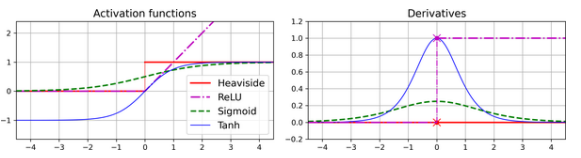

But, why do we need Activation Functions at all? The answer is that Artificial Neurons without Activation Function are just chains of several Linear Transformation, which end in getting a new Linear Transformation that can't solve very complex problems; if we instead add these Activation Function, we are basically adding some **Non-Linearity** between layers, allowing to approximate, at least theoretically, any continuous function.

## 3. MLPs with Scikit-Learn
Let's start using MLPs for Regression and Classification:

### Regression MLPs
When building an MLP for regression, we first need to understand how many values we are interested in predicting:
- predicting a single value like a price;
- predicting two coordinates when predicting the center of an object in an image;
- predicting height, width and center of a bounding box.

Our MLP will have one Output Neuron for each of these values. Let's implement one MLP in Scikit-Learn with 3 Hidden Layers of 50 Neurons each, and train it on the California housing dataset (we'll use the `fetch_california_housing()` function to load the dataset in a simpler version with only numerical features and there are no missing values; features are also scaled down, where each unit represents $100,000).

We first import the needed functions:

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

We then fetch the dataset and split it:

In [3]:
housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, random_state=42)

We now use `MLPRegressor` to create the model with 3 Hidden Layers composed of 50 Neurons each: the first Hidden Layer's input size (i.e., the number of rows in its weights matrix) and the Output Layer's output size (i.e., the number of columns in its weights matrix) will adjust automatically to the dimensionality of the Inputs and Targets respectively. The model also uses the ReLU activation function in all Hidden Layers and no activation function in the Output Layer. We also set `verbose=True` to get details on the model's progress during training:

In [4]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], early_stopping=True, verbose=True, random_state=42, )

Since NNs have lot of parameters, they tend to overfit. We're using `early_stopping=True` to reduce this risk: this automatically sets aside `validation_fraction` of training data (default is 0.1) and uses it to evaluate the model at each epoch: if the validation score stops improving for `n_iter_no_change` epochs (default is 10), training will stop. The `MLPRegressor` uses `solver="adam"`, which is a variant of Gradient Descent to minimize the mean squared error; it also uses $l2$ regularization `alpha=0.0001`.

Let's make a pipeline which before fitting the MLP, scales the features (we already saw in Chapter 4 how Gradient Descent does not converge well with different scales features):

In [5]:
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)

Iteration 1, loss = 0.85190332
Validation score: 0.534299
Iteration 2, loss = 0.28288639
Validation score: 0.651094
Iteration 3, loss = 0.22884372
Validation score: 0.699782
Iteration 4, loss = 0.20746145
Validation score: 0.720468
Iteration 5, loss = 0.19649383
Validation score: 0.724839
Iteration 6, loss = 0.18928708
Validation score: 0.740084
Iteration 7, loss = 0.18132029
Validation score: 0.747406
Iteration 8, loss = 0.17556450
Validation score: 0.753945
Iteration 9, loss = 0.17190651
Validation score: 0.760500
Iteration 10, loss = 0.16687650
Validation score: 0.759213
Iteration 11, loss = 0.16329479
Validation score: 0.761907
Iteration 12, loss = 0.16054473
Validation score: 0.768950
Iteration 13, loss = 0.15690181
Validation score: 0.762699
Iteration 14, loss = 0.15630644
Validation score: 0.766003
Iteration 15, loss = 0.15712517
Validation score: 0.778464
Iteration 16, loss = 0.15155981
Validation score: 0.774237
Iteration 17, loss = 0.14957641
Validation score: 0.778361
Iterat

,steps,"[('standardscaler', ...), ('mlpregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,hidden_layer_sizes,"[50, 50, ...]"
,activation,'relu'
,solver,'adam'


Your first MLP took 45 epochs to train! We can see how the training loss went down each epoch (note how this is the Ridge cost function and not the MSE) and validation score (by default in Scikit this is the $R^2$) went up almost at each epoch, reaching around 80% of explained variance on the validation set. Note how we used the MSE (with regularization), but another common possibility is to use the MAE (when we have lot of outliers), or preferably the **Huber Loss** (it is a combination of both): unfortunately this is not supported in the `MLPRegressor` class.

Let's print the best Validation MSE:

In [6]:
mlp_reg.best_validation_score_

0.791536125425778

Let's instead compute the Test RMSE:

In [7]:
y_pred = pipeline.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

0.5327699946812925

A Test RMSE around 0.53, which is comparable to what we would get with a Random Forest Classifier.

Note how we didn't put any Activation Function for the Output Layer, meaning it can output any value it wants: this is generally fine, but we could use an Activation Function such as the ReLU or the **Softplus** Activation Function to guarantee output is always positive:

$$softplus(z) = \log(1+exp(z))$$

The Softplus is a smooth variant of the ReLU: when $z$ is negative, it is close to 0, when $z$ is positive, it is close to $z$.

Another possiiblity is that we could want the predictions to always fall within a given range: in this case we could use the Sigmoid (for the range 0 to 1) or the Tanh (for the range -1 to 1); unfortunately, these 2 are not supported by the `MLPRegressor` class.

Remember also that Scikit-Learn doesn't allow GPU acceleration and other NN features: this is why we will switch to PyTorch in Chapter 10.

Below a typical MLP architecture for Regression:

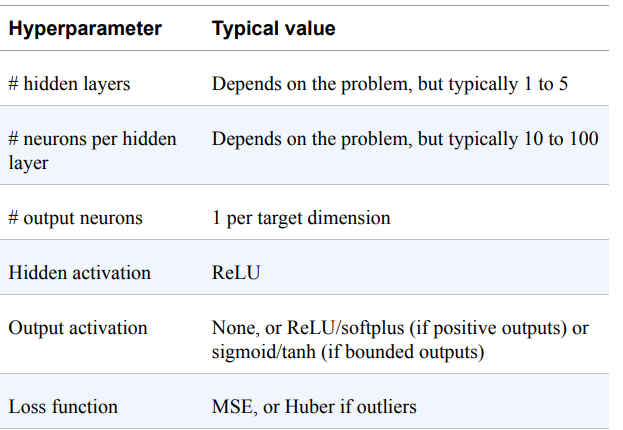

### Classification MLPs
As we said before, we can bound the outputs of the MLP by putting a Sigmoid or Tanh Activation Function at the end of the Output Layer: to use MLP for a binary classification task we put a Sigmoid Function limiting the output to be a number between 0 and 1, which we will interpret as the estimated probability of the positive class.

For a multilabel binary classification, we would have 1 Output Neuron for each positive class and a Signoid activation function.

For multiclass classification (more than 2 classes), we would have 1 Output Neuron per possible class and a Softmax activation function (Chapter 4): this allowa to have estimated probabilities between 0 and 1, and that they add up to 1 (classes are esclusive).

The loss function is the Cross-Entropy Loss (also called **x-entropy** or **log loss**).

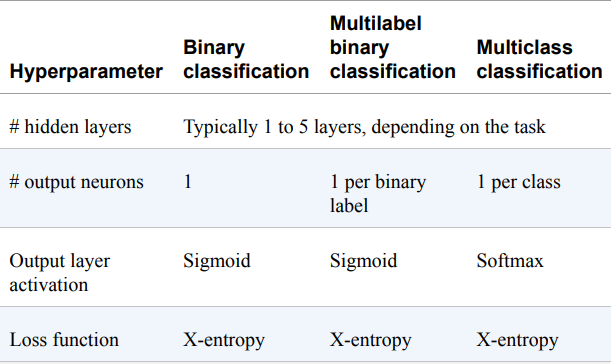

In Scikit-Learn, we got the `MLPClassifier` class: this is almost identical to the `MLPRegressor`, except that the Output Layer uses the Softmax Activation Function and it minimizes Cross-Entropy; moreovers when calling `.score()` it returns the Accuracy instead of the $R^2$.

Let's try to implement one on the Fashion MNIST dataset: 70,000 grayscale 28x28 images with 10 classes of fashion items images (this is significantly more challenging than the handwritten digit considering a linear model reaches about 92% on MNIST and about 83% on Fashion MNIST).

We first load the dataset (at the time writing this, the function `fetch_openml()` gives an URLError, so we'll get the dataset from Kaggle): 

In [8]:
import kagglehub
import os
import idx2numpy
import pandas as pd

# Use Kaggle API
data_dir = kagglehub.dataset_download("zalando-research/fashionmnist")

# Get each file path
train_images_path = os.path.join(data_dir, "train-images-idx3-ubyte")
train_labels_path = os.path.join(data_dir, "train-labels-idx1-ubyte")
test_images_path = os.path.join(data_dir, "t10k-images-idx3-ubyte")
test_labels_path = os.path.join(data_dir, "t10k-labels-idx1-ubyte")

# Convert the IDX Binary Files to numpy
X_train = idx2numpy.convert_from_file(train_images_path)
y_train = idx2numpy.convert_from_file(train_labels_path)
X_test = idx2numpy.convert_from_file(test_images_path)
y_test = idx2numpy.convert_from_file(test_labels_path)

# Flatten 
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

/home/essskevin/projects/hands_on_ml/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We obtain 60,000 training images and 10,000 testing images, each represented as a 1D array containing 784 pixel intensities ranging from 0 to 255. Each image label can be one of the below:

In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Let's plot the first image in the training set and its label:

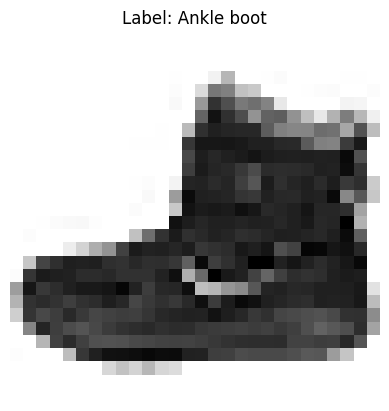

In [10]:
import matplotlib.pyplot as plt

X_sample = X_train[0].reshape(28, 28)
plt.imshow(X_sample, cmap = 'binary')
plt.title(f'Label: {class_names[y_train[0]]}')
plt.axis('off')
plt.show()

Let's now build the classifier:

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler

mlp_clf = MLPClassifier(hidden_layer_sizes=[300, 100], verbose=True, early_stopping=True, random_state=42)
pipeline = make_pipeline(MinMaxScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)

Iteration 1, loss = 0.55394420
Validation score: 0.854833
Iteration 2, loss = 0.39017365
Validation score: 0.867500
Iteration 3, loss = 0.34572472
Validation score: 0.877500
Iteration 4, loss = 0.31541926
Validation score: 0.881167
Iteration 5, loss = 0.29351007
Validation score: 0.887167
Iteration 6, loss = 0.28459028
Validation score: 0.889167
Iteration 7, loss = 0.26775210
Validation score: 0.885500
Iteration 8, loss = 0.25610516
Validation score: 0.886667
Iteration 9, loss = 0.24488907
Validation score: 0.893167
Iteration 10, loss = 0.23915583
Validation score: 0.888500
Iteration 11, loss = 0.22290961
Validation score: 0.897167
Iteration 12, loss = 0.21925185
Validation score: 0.889667
Iteration 13, loss = 0.21249406
Validation score: 0.892167
Iteration 14, loss = 0.20374069
Validation score: 0.891333
Iteration 15, loss = 0.19557455
Validation score: 0.893833
Iteration 16, loss = 0.19099949
Validation score: 0.893667
Iteration 17, loss = 0.18445775
Validation score: 0.890333
Iterat

This is similar to the regression code except for few differencies:
- we have just 2 Hidden Layers with 300 and 100 neurons respectively; 
- we used `MinMaxScaler` to shrink pixel values in the range 0-1: this usually works better with default parameters of `MLPClassifier`; moreover, we used this instead of `StandardScaler` because it usually works better for images (the idea is that having a lot of white pixels in the edges, with `StandardScaler` we would scale these up to have the same variance of other pixels, giving them more importance than they probably deserve);
- as we said, `score()` returns the accuracy.

Let's check the best Validation Accuracy:

In [12]:
mlp_clf.best_validation_score_

0.9023333333333333

And the Test Accuracy:

In [13]:
accuracy

0.8929

We got a good performance for this task with this model (in Chapter 12 we'll see how Convolutional Neural Networks are better suited for this).

We can use the model to predict new instances with `predict()`:

In [14]:
X_new = X_test[:15]

mlp_clf.predict(X_new)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4], dtype=uint8)

All of the above are correct except for the index 12 which should be a 7 (sneaker) instead of a 5 (sandal).

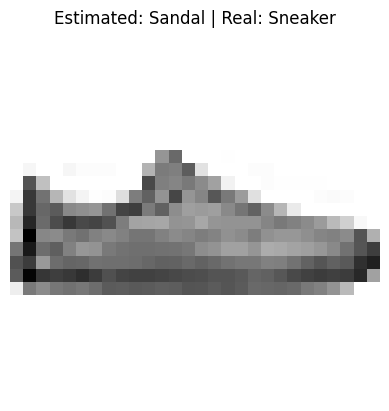

In [15]:
plt.imshow(X_new[12].reshape(28, 28), cmap = 'binary')
plt.axis('off')
plt.title(f'Estimated: {class_names[mlp_clf.predict(X_new)[12]]} | Real: {class_names[y_test[12]]}')
plt.show()

We can get the estimated probabilities with `predict_proba()` to check how confident the model is when misclassifying that image:

In [16]:
mlp_clf.predict_proba(X_new)[12]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

The model is wrong and it is also 100% confident it's right! This shows the tendency of NNs to be overconfidend, especially if they are trained a bit too long. One way to deal with this is by **Label Smoothing Technique** (i.e., reduce the target class's probability slightly).

### Hyperparameter Tuning
The flexibility of NNs is one of the main advantages but also one of the main drawbacks of them: we have many hyperparameters to tweak; in an MLP, these are the number of layers, the number of neurons, the activation function to use in each layer, the weight initialization logic, the type of optimizer to use, its learning rate, the batch size and so on.

Let's see some good values for these hyperparameters:

#### Number of Hidden Layers
An MLP with just one hidden layer can theoretically model even the most complex functions if it has enough neurons, but Deep Networks have a much higher **Parameter Efficiency**: they can model complex functions using exponentially fewer neurons; this is because the layered structure enables them to reuse and compose features across multiple levels (e.g., when building a face classifier, the first layer may learn to recognize low-level features such as dots, arcs, straight lines, while the second layer may learn to combine these into squares, circles and the third layer may learn to combine them into a mouth, a nose, an eye, and the last layer would then be able to classify faces). This helps them converge faster.

Another big advantage of this is their ability to generalize to new datasets (e.g., the weights of that trained face classifier could be used in the initialization of a hairstyles classifier, so that the network won't need to learn from scratch all the low-level structures): this is **Transfer Learning**.

In summary, you can start with 1 or 2 hidden layers for many problems (e.g., on the MNIST dataset one layer with few hundred neurons reach 97% accuracy, while two layers with same number of total neurons and roughly same training time go above 98%); for more complex problems, you can increase the number of hidden layers until the model starts overfitting; for very complex tasks (e.g., image classification or speech recognition) even dozens or hundreds of layers (not fully connected as you will see in Chapter 12) with huge amount of data may be needed. Consider that in this cases you rarely will train such networks from scratch, but it is much more common to reuse pre-trained parts of a state-of-the-art network used for similar tasks.

#### Number of Neurons per Hidden Layer
The number of neurons in the Input and Output layers is determined by the type of input and output your task requires (e.g., MNIST task requires 28 x 28 = 784 inputs and 10 output neurons).

For the Hidden Layer, one farly used approach was to form a pyramid, with fewer and fewer neurons at each layer (the idea was that many low-level features can together get to a fewer high-level features); this practice has been largely abandoned, because it seems that using same number of neurons in all Hidden Layers performs just as well, or even better (depending on the dataset, it may help make the first Hidden Layer a bit larger than the others).

Just as the number of layers, you can try increasing the neurons in a network until the network starts overfitting (it is generally more effective to increase the number of layers rather than the number of neurons per layer).

Alternatively, you can put slightly more layers and neurons than you actually need and use Early Stopping, or other regularization techniques, to prevent it from overfitting. This approach has been called **Stretch Pants**: instead of wasting time looking for pants perfectly matching your size, use large stretch pants and shrink them down to your size. This approach avoids **Bottleneck**. However, putting too much neurons will take more time and data to train.

Note that Bottleneck Layers are not always a bad thing: they can be used to force the NN to keep only the most important dimensions deleting noise in data or to learn a good representations of the data in the previous layers (i.e., putting more useful information in less space), which can be useful for **Representation Learning** (Chapter 18).



#### Learning Rate
In general, the optimal learning rate is about half of the maximum learning rate (i.e., the learning rate above which training algorithm diverges).

One way to find a good learning rate is to train the model for few hundred iterations, starting with very low learning rate (e.g., $10^{-5}$) and gradually increasing it to a very large value (e.g., 10) by multiplying it by a constant factor at each iteration (e.g., $(10 / 10^{-5})^{1/500}$, so that you reach the large value in 500 iterations); if you then plot the loss as a function of the log of the learning rate, you'll see the loss dropping at first, then the learning rate will be too high and let the loss will shoot back up: the optimal learning rate is often a bit lower than the point at which the loss starts to climb (typically 10 times lower); you can then reinitialize the model and train it using that learning rate.

This can be done in Scikit-Learn by setting `warm_start=True` and calling `partial_fit()`, updating the learning rate at each iteration.

#### Batch Size
This has significant impact on model's performance and training time: large batch sizes allow hardware accelerators like GPUs to process them efficiently (more instances are seen per seconds), so many researchers recommend using the largest batch size fitting in the VRAM.

However, large batch sizes can sometimes lead to training instabilities, especially with smaller models at start of training, taking the model to not generalize well; LeCun, in a 2018 [paper](https://arxiv.org/abs/1804.07612) suggested using smaller batch size, from 2 to 32.

In 2017 [Elad Hoffer et al.](https://arxiv.org/abs/1705.08741) and [Priya Goyal et al.](https://arxiv.org/abs/1706.02677) showed it is possible to use very large batch sizes (up to 8,192) along with other techniques, such as warm start.

To sum up, one strategy may be to use very large batch size, possibly with learning rate warmup, and then try smaller batch size if the training is unstable.

#### Optimizer
This should be tuned only if you have computation budget and time: you can try choosing a better optimizer than Mini-Batch Gradient Descent and tune its hyperparameters.

#### Activation Function
This should be tuned only if you have computation budget and time: in general, ReLU is a good default for Hidden Layers, but replacing it may help in some cases.

#### Best Practices Regarding Hyperparameters Tuning
Check this 2018 [paper](https://arxiv.org/abs/1803.09820) by Leslie Smith, this [Deep Learning Playbook](https://github.com/google-research/tuning_playbook) by Google researchers, or this [Machine Learning Yearning e-book](https://info.deeplearning.ai/machine-learning-yearning-book) by Andrew Ng.

Most importantly, try playing with this [web app](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.85882&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false).